In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import os

# load .env
from dotenv import load_dotenv
load_dotenv(dotenv_path='../.env')

# get from environment variable
dataset_path = os.environ['DATASET_PATH']
dataSet = pd.read_parquet(dataset_path)

features = dataSet.columns

temporalColumns = dataSet["first_timestamp"]

dataSet['first_timestamp'] = pd.to_datetime(dataSet['first_timestamp'])


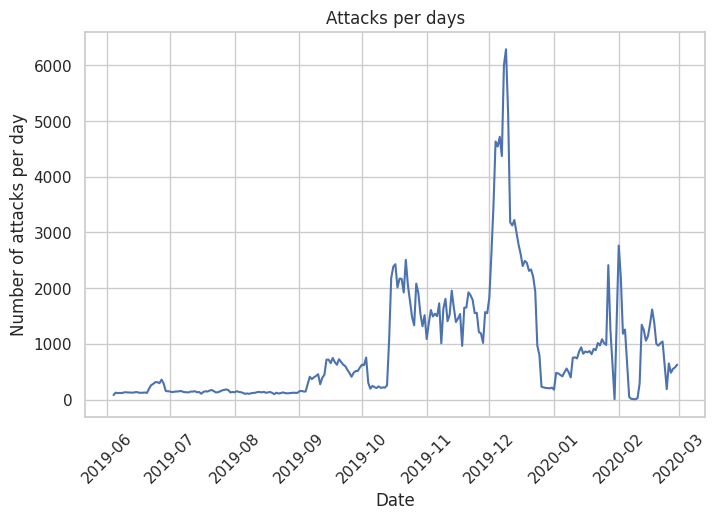

In [39]:

attacks_per_day = (
    dataSet.groupby(dataSet['first_timestamp'].dt.date)
           .size()
           .reset_index(name="number_of_attacks_per_day")
)

#-----------------------PLOT-----PER-NUMERO-ATTACCHI-------------------------------
plt.figure(figsize= (8,5))
plt.plot(attacks_per_day["first_timestamp"], attacks_per_day["number_of_attacks_per_day"])

plt.xticks(rotation=45)

plt.title("Attacks per days")
plt.xlabel("Date")
plt.ylabel("Number of attacks per day")
plt.show()
#------------------------------------------------------------------------------------





Codice per le distribuzioni di numero di caratteri per ogni sessione e numero di parole presenti per ogni sessione di attacco.

In [40]:
# Preprocessing of full_session to decode encoded attacks (base64)
import re
import base64
import string

# if there's "base64" in the payload, try to decode it (find base64 strings longer than 20 characters with regex)
# replace just the found substring, not the whole payload
def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)
# Example of decoded payloads when base64 is detected
# print("Examples of decoded payloads:")
# print(df_copy[df_copy['full_session'].str.contains('base64', na=False)]['decoded_payload'].head(5))

DBG_DECODE = False

if DBG_DECODE:
    with open('decoded_payloads.txt', 'w') as f:
        for payload in dataSet[dataSet['full_session'].str.contains('base64', na=False)]['decoded_payload'].head(100):
            # write original and decoded payload, each separated by a line of dashes
            f.write("Original Payload:\n")
            f.write(dataSet[dataSet['full_session'].str.contains('base64', na=False)]['full_session'].head(100).iloc[0])
            f.write("\nDecoded Payload:\n")
            f.write(payload)
            f.write("\n" + "-"*80 + "\n")


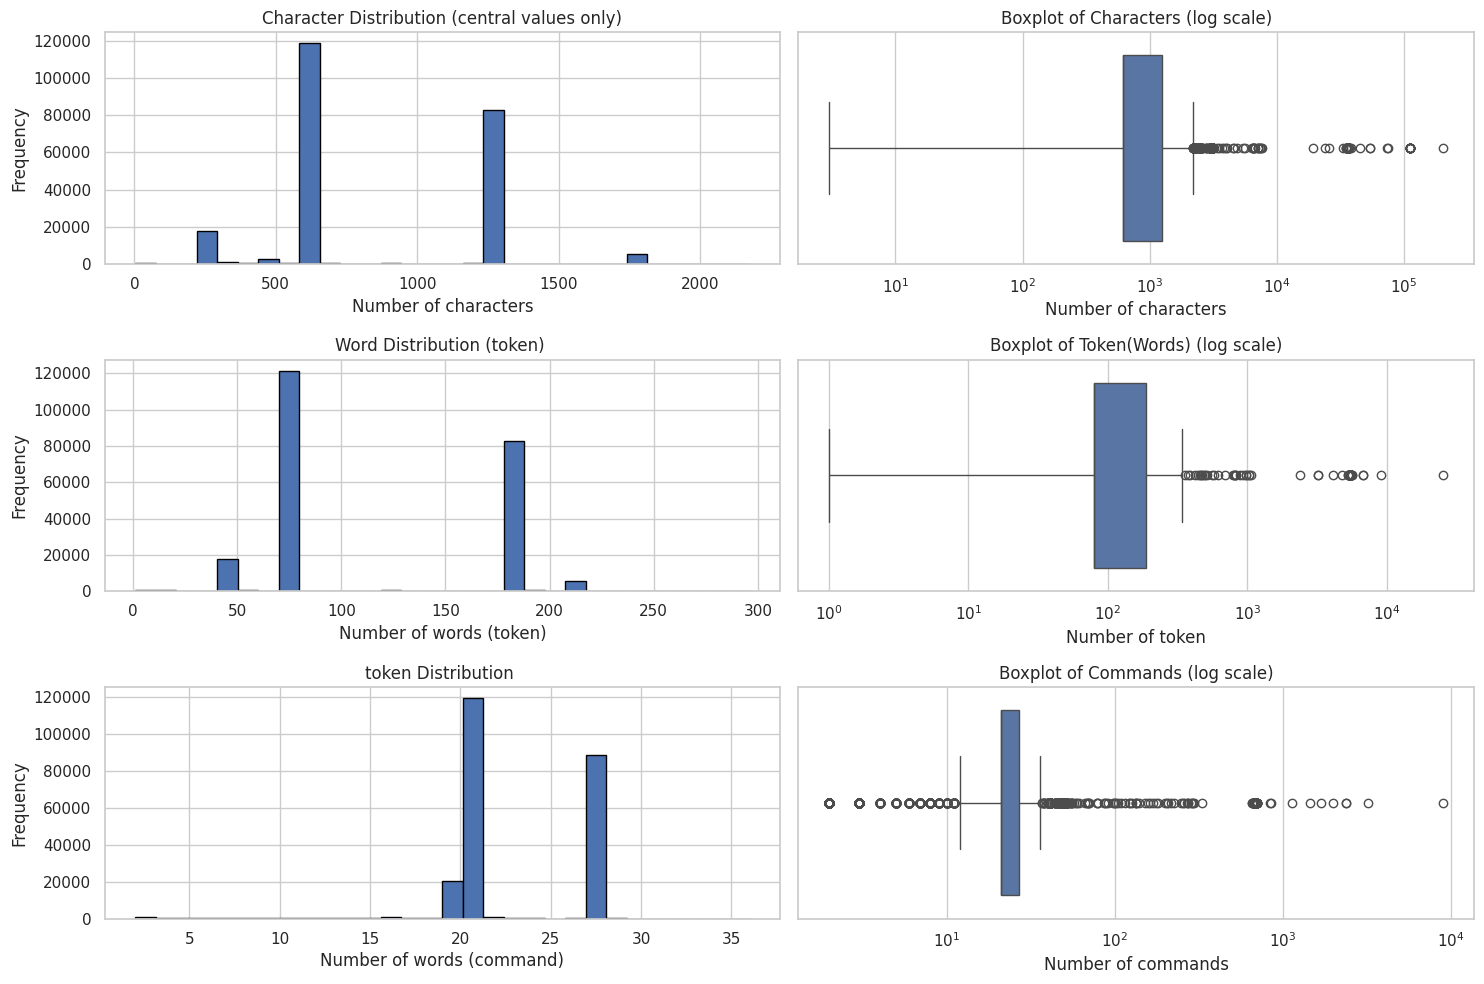

Max characters: 203442
Max words: 25430
Upper bound for outliers: 2181.5
Percentage of outliers: 0.42568712854291757 %


In [47]:
sessionCodeLen = dataSet[["decoded_payload"]].copy()
sessionCodeLen["number_of_characters"] = sessionCodeLen["decoded_payload"].str.len()

sessionWordsLen = dataSet[["decoded_payload"]].copy()
word_pattern = re.compile(r'[^\s|;(){}:\'\">]+')
# sessionWordsLen["number_of_words_token"] = sessionWordsLen["decoded_payload"].str.split(r";|\||&&|\|\||>>|>|<|&").str.len()
# use regex instead of str.split to count words
sessionWordsLen["number_of_words_token"] = sessionWordsLen["decoded_payload"].apply(lambda x: len(word_pattern.findall(x)))

sessionWordsLen["number_of_words_command"] = sessionWordsLen["decoded_payload"].str.split(r";").str.len()


# Calcolo outlier con metodo IQR
q1 = sessionCodeLen["number_of_characters"].quantile(0.25)
q3 = sessionCodeLen["number_of_characters"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

q1_w = sessionWordsLen["number_of_words_token"].quantile(0.25)
q3_w = sessionWordsLen["number_of_words_token"].quantile(0.75)
iqr_w = q3_w - q1_w
upper_bound_w = q3_w + 1.5 * iqr_w

q1_w2 = sessionWordsLen["number_of_words_command"].quantile(0.25)
q3_w2 = sessionWordsLen["number_of_words_command"].quantile(0.75)
iqr_w2 = q3_w2 - q1_w2
upper_bound_w2 = q3_w2 + 1.5 * iqr_w2

central_chars = sessionCodeLen[sessionCodeLen["number_of_characters"] <= upper_bound]

central_words = sessionWordsLen[(sessionWordsLen["number_of_words_token"] <= upper_bound_w) & (sessionWordsLen["number_of_words_command"] <= upper_bound_w2)]


# === 2) Plotting =============================================

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
sns.set(style="whitegrid")

# --- (A) Istogramma SENZA outlier -----------------------------
axes[0, 0].hist(central_chars["number_of_characters"], bins=30, edgecolor="black")
axes[0, 0].set_title("Character Distribution (central values only)")
axes[0, 0].set_xlabel("Number of characters")
axes[0, 0].set_ylabel("Frequency")


# --- (B) Boxplot completo con outlier -------------------------
sns.boxplot(x=sessionCodeLen["number_of_characters"], ax=axes[0, 1])
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Boxplot of Characters (log scale)")
axes[0, 1].set_xlabel("Number of characters")



# --- (C) Istogramma parole con eliminazione outlier ----------------------
axes[1, 0].hist(central_words["number_of_words_token"], bins=30, edgecolor="black")

axes[1, 0].set_title("Word Distribution (token) ")
axes[1, 0].set_xlabel("Number of words (token)")
axes[1, 0].set_ylabel("Frequency")


# --- (D) Boxplot completo con outlier in scala log -------------------------
sns.boxplot(x=sessionWordsLen["number_of_words_token"], ax=axes[1, 1])
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Boxplot of Token(Words) (log scale)")
axes[1, 1].set_xlabel("Number of token")

# --- (E) Istogramma parole con eliminazione outlier ----------------------
axes[2, 0].hist(central_words["number_of_words_command"], bins=30, edgecolor="black")

axes[2, 0].set_title("token Distribution ")
axes[2, 0].set_xlabel("Number of words (command)")
axes[2, 0].set_ylabel("Frequency")

# --- (F) Istogramma parole con eliminazione outlier ----------------------
sns.boxplot(x=sessionWordsLen["number_of_words_command"], ax=axes[2, 1])
axes[2, 1].set_xscale("log")
axes[2, 1].set_title("Boxplot of Commands (log scale)")
axes[2, 1].set_xlabel("Number of commands")




plt.tight_layout()
plt.show()




# === 3) Statistiche utili =====================================

print("Max characters:", sessionCodeLen["number_of_characters"].max())
print("Max words:", sessionWordsLen["number_of_words_token"].max())
print("Upper bound for outliers:", upper_bound)
print("Percentage of outliers:",
      (1 - len(central_chars) / len(sessionCodeLen)) * 100, "%")



Codice per il punto 3 della sezione 1

In [42]:
# sessionWordsLen["common_words_token"] = sessionWordsLen["decoded_payload"].apply(
#         lambda s: Counter([tok.strip()
#               for cmd in re.split(r";|\||&&|\|\||>>|>|<|&", s)
#               for tok in cmd.split()
#               if tok.strip()]).most_common(1)[0][0] if isinstance(s, str) else None
# )
# print(sessionWordsLen)

# === Most common words (tokens) =============================
from collections import Counter
all_tokens = []
for session in dataSet["decoded_payload"]:
    tokens = re.split(r'[ \t\n|;(){}:\'\">]+', session.lower())
    tokens = [t for t in tokens if t]  # Remove empty tokens
    all_tokens.extend(tokens)
token_counts = Counter(all_tokens)
most_common_tokens = token_counts.most_common(20)
print("\nMost common words (tokens):")
for token, count in most_common_tokens:
    print(f"{token}: {count}")
sessionWordsLen["common_words_command"] = sessionWordsLen["decoded_payload"].apply(
        lambda s: Counter([cmd.strip()
              for cmd in re.split(r";", s)
              if cmd.strip()]).most_common(1)[0][0] if isinstance(s, str) else None
)


#-----------------------------------stampa per i token----------------------------------
# print(f"Questa è la parola in senso di token più comune tra i vari comandi di sessione: {sessionWordsLen["common_words_token"].value_counts().idxmax()}")


#----------------------------stampa per i comandi interi-------------------------------
print(f"Questa è la parola in senso di comandi più comune tra i vari comandi di sessione: {sessionWordsLen["common_words_command"].value_counts().idxmax()}")


Most common words (tokens):
grep: 1278540
cat: 1083405
echo: 957788
1: 873983
-l: 818589
rm: 814319
-rf: 793808
uname: 639144
/proc/cpuinfo: 638867
name: 638783
/var/tmp/.var03522123: 637129
0: 623756
ls: 518448
`@: 502766
cd: 486764
print: 426397
awk: 426387
-m: 426324
-n: 425644
head: 425589
Questa è la parola in senso di comandi più comune tra i vari comandi di sessione: cat /proc/cpuinfo | grep name | wc -l


Analisi delle distribuzioni

Intent distribution:
Discovery: 232145
Persistence: 211295
Execution: 92927
Defense Evasion: 18999
Harmless: 2206
Other: 327
Impact: 27
                                           L'intent più numeroso è Discovery                                            


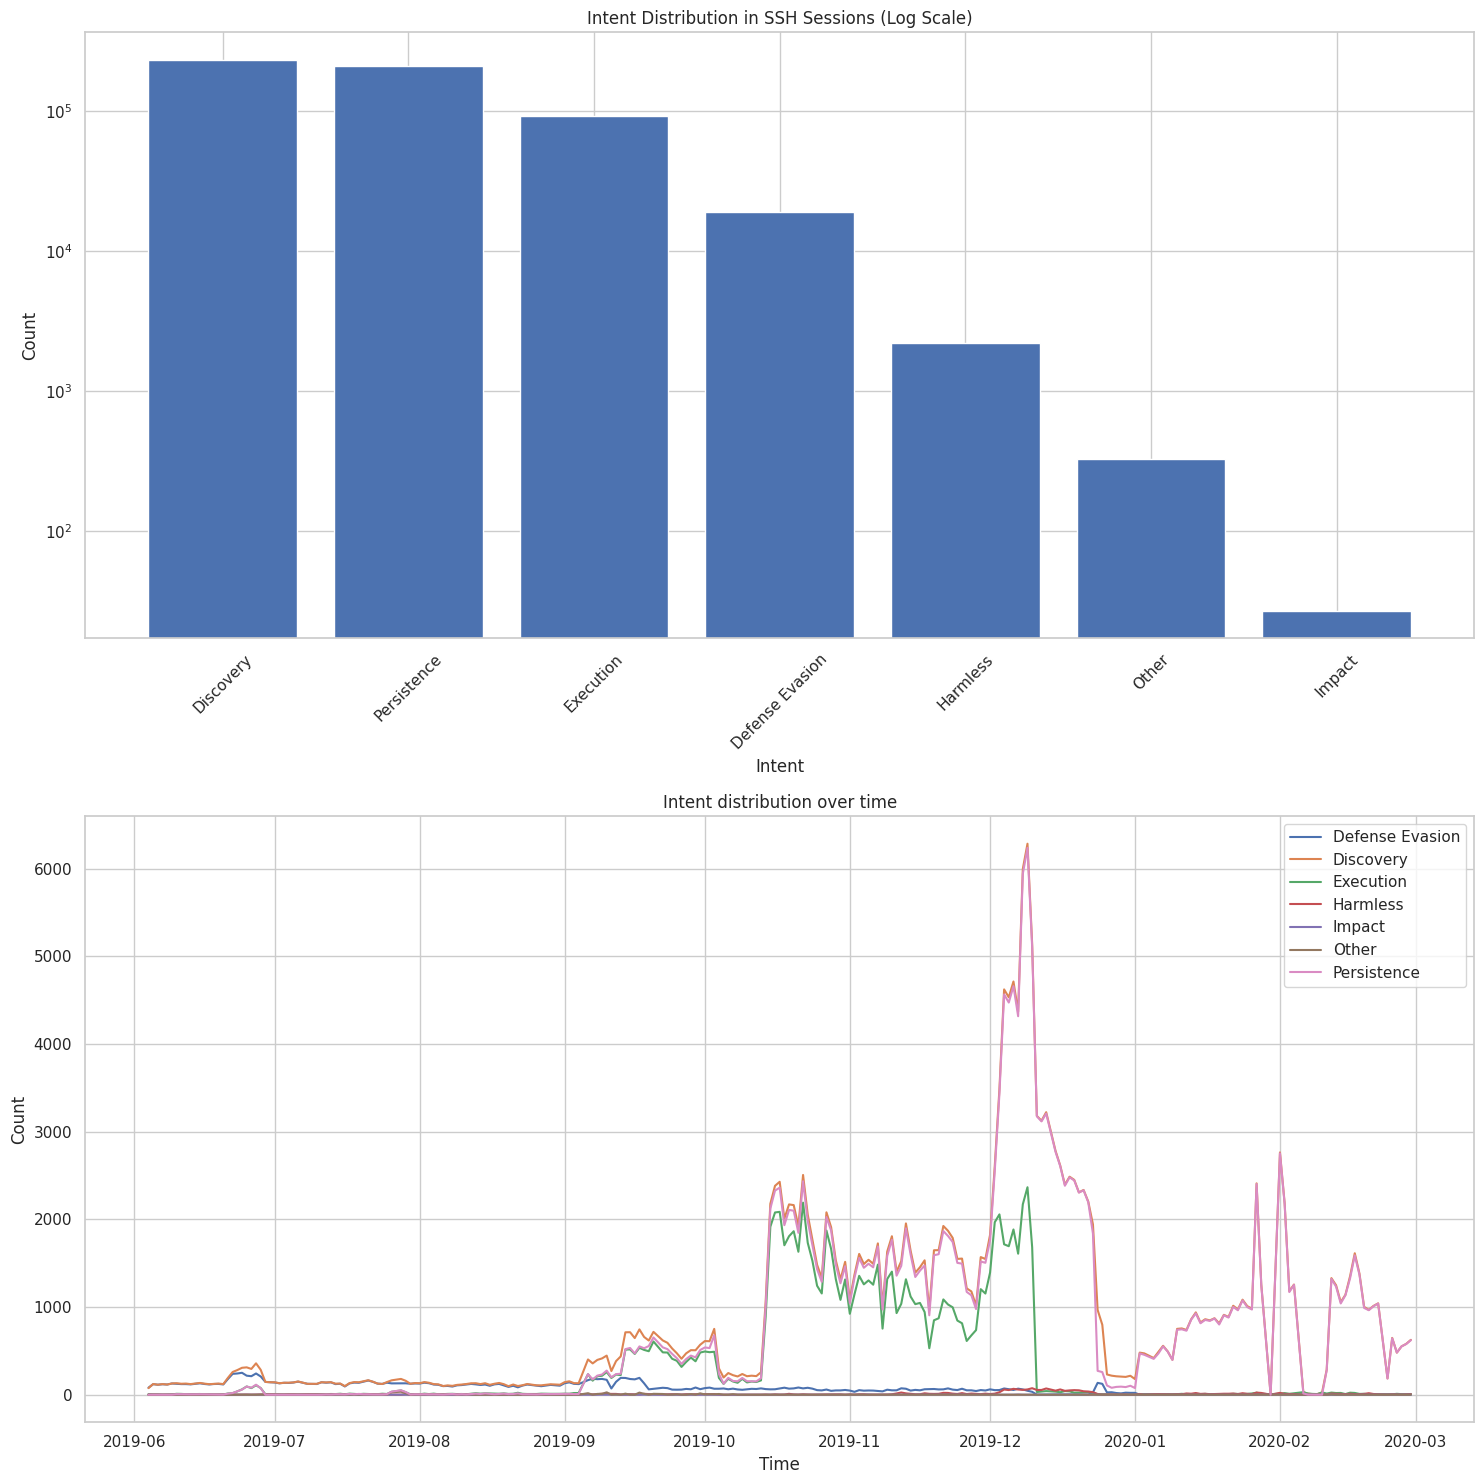

In [43]:
sessionIntents = dataSet[["Set_Fingerprint"]].copy()
sessionIntents["Time"] = dataSet["first_timestamp"]

#calcolo del common intent

exploded = sessionIntents.explode('Set_Fingerprint')

global_common = exploded['Set_Fingerprint'].value_counts().idxmax()

sessionIntents["numberOfIntentsPerSession"] = sessionIntents["Set_Fingerprint"].str.len()


from collections import defaultdict
intent_counts = defaultdict(int)
for intents in dataSet['Set_Fingerprint']:
    for intent in intents:
        intent_counts[intent] += 1
sorted_intent_counts = sorted(intent_counts.items(), key=lambda x: x[1], reverse=True)
print("Intent distribution:")
for intent, count in sorted_intent_counts:
    print(f"{intent}: {count}")

# Plot the intent distribution as a bar chart
intents, counts = zip(*sorted_intent_counts)

#-----------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 15))


axes[0].bar(intents, counts, log=True)
axes[0].set_title("Intent Distribution in SSH Sessions (Log Scale)")
axes[0].set_xlabel("Intent")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)


#-----------------------------------------------------------------------------------------
groupIntents = sessionIntents.groupby("Set_Fingerprint")


#---------------------------------------------------------------------------------------------
print(f"{f"L'intent più numeroso è {global_common}":^120}")

#----------------------------------------ANALISI-TEMPORALE------------------------------------

exploded["day"] = exploded["Time"].dt.floor("D")
distribution_time = (
    exploded
    .groupby(["day", "Set_Fingerprint"])
    .size()
    .unstack(fill_value=0)
)




for intent in distribution_time.columns:
    plt.plot(distribution_time.index,
             distribution_time[intent],
             label=intent)

axes[1].set_title("Intent distribution over time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_37499/3802378191.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


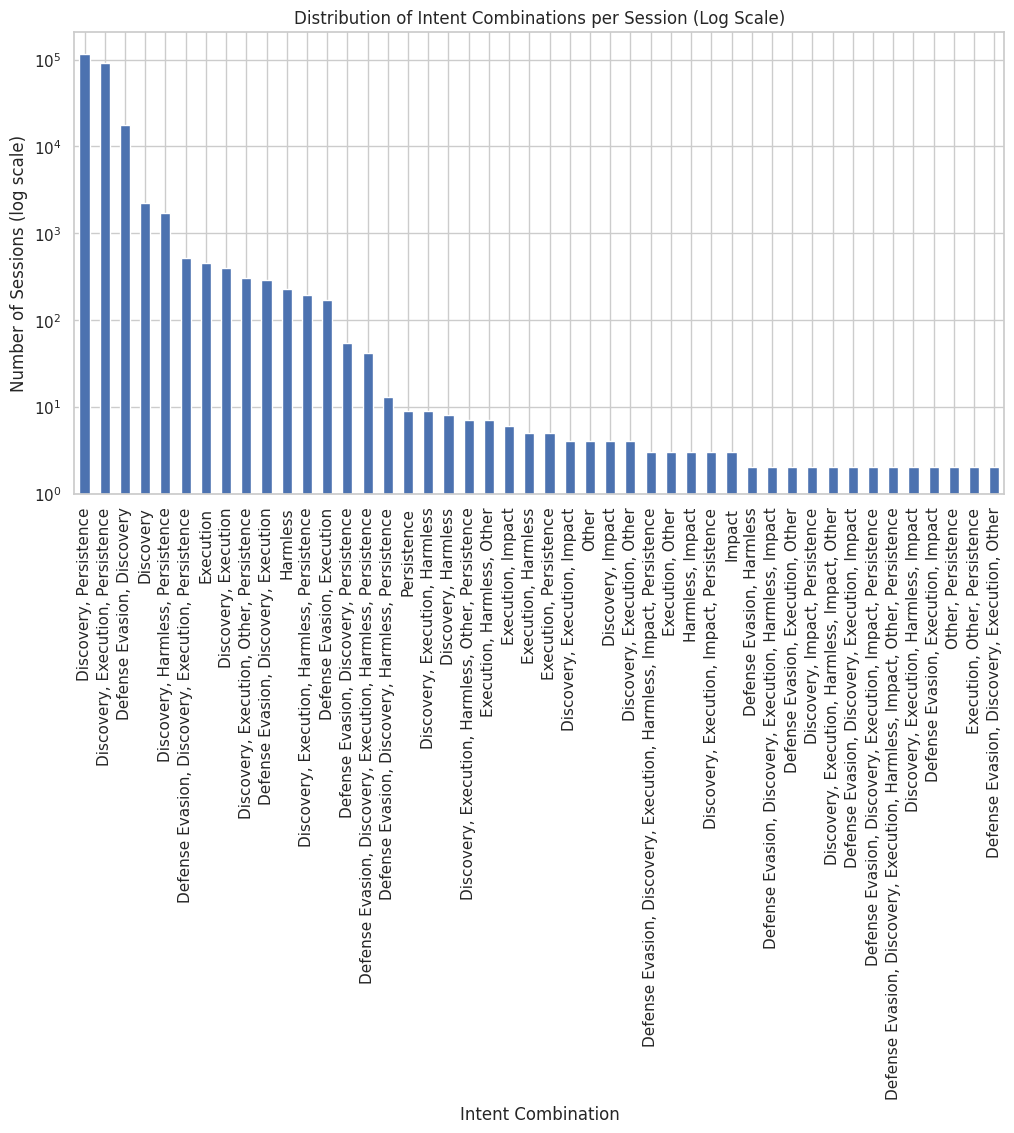

In [44]:
# Create a string representation of the sorted intents per session
dataSet['intents_str'] = dataSet['Set_Fingerprint'].apply(lambda x: ', '.join(sorted(x)))
# Count the frequency of each unique intent combination
intent_combo_counts = dataSet['intents_str'].value_counts()

plt.figure(figsize=(12, 6))
intent_combo_counts.plot(kind='bar', log=True)
plt.title('Distribution of Intent Combinations per Session (Log Scale)')
plt.xlabel('Intent Combination')
plt.ylabel('Number of Sessions (log scale)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Codice per le (BoW)

In [45]:
vectorizerBoW = CountVectorizer(token_pattern=r'[^\s|;(){}:\'\">]+')

X = vectorizerBoW.fit_transform(dataSet["decoded_payload"])

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 15080914 stored elements and shape (233035, 399953)>
  Coords	Values
  (0, 140266)	1
  (0, 342179)	1
  (0, 327758)	1
  (0, 326779)	1
  (0, 109322)	3
  (0, 9173)	1
  (0, 8438)	4
  (0, 320182)	4
  (0, 110199)	1
  (0, 8473)	1
  (0, 7706)	5
  (0, 119598)	1
  (0, 8440)	1
  (0, 348159)	1
  (0, 374872)	1
  (0, 126041)	1
  (0, 105193)	1
  (0, 119447)	1
  (0, 177647)	1
  (0, 375108)	1
  (0, 307805)	1
  (0, 175208)	1
  (0, 131603)	1
  (0, 137014)	1
  (0, 5958)	1
  :	:
  (233034, 150691)	1
  (233034, 7247)	2
  (233034, 221813)	1
  (233034, 5439)	1
  (233034, 7021)	1
  (233034, 5442)	1
  (233034, 5444)	1
  (233034, 5448)	1
  (233034, 5449)	1
  (233034, 7246)	1
  (233034, 5389)	1
  (233034, 375106)	1
  (233034, 120715)	1
  (233034, 370765)	1
  (233034, 226458)	2
  (233034, 352683)	1
  (233034, 213379)	1
  (233034, 7204)	1
  (233034, 267556)	2
  (233034, 9942)	1
  (233034, 67214)	1
  (233034, 10169)	1
  (233034, 297224)	1
  (233034, 297321)

TF-IDF

In [46]:
vectorizerTF = TfidfVectorizer(token_pattern=r'[^\s|;(){}:\'\">]+')

X2 = vectorizerTF.fit_transform(dataSet["decoded_payload"])

tokens = vectorizerTF.get_feature_names_out()

# X2 = matrice sparse TF-IDF
# row.data e row.indices valgono per riga, ma qui serve tutta la matrice

# convertiamo la matrice sparsa in formato COO (facile da manipolare)
X_coo = X2.tocoo()

# indici delle 5 voci più alte
top_idx = np.argsort(X_coo.data)[-5:][::-1]

for idx in top_idx:
    row_idx = X_coo.row[idx]
    col_idx = X_coo.col[idx]
    value = X_coo.data[idx]
    token = tokens[col_idx]
    print(f"Sessione {row_idx}, Token: {token}, TF-IDF: {value:.3f}")


Sessione 10093, Token: w, TF-IDF: 1.000
Sessione 4316, Token: exit, TF-IDF: 1.000
Sessione 89356, Token: shell, TF-IDF: 1.000
Sessione 80833, Token: passwd, TF-IDF: 1.000
Sessione 194639, Token: uname, TF-IDF: 1.000
